# probreg CPD/FilterReg vs. own ICP

Compares probreg's rigid Coherent Point Drift and FilterReg against this project's own ICP (Gaussian-matcher and nearest-neighbor-matcher variants), each run as `MultiStartICP` with the same number of restarts, on the same synthetic experiments, using the same error-curve/table layout as `8_rainbow_icp.ipynb`.

probreg's GMMTree is excluded: it hangs unpredictably on certain random-rotation starts (a probreg-internal issue), which multi-start's random restarts reliably trigger.

Requires the **"Python 3.12 (probreg)"** kernel (`.venv-probreg`) — `probreg`'s dependency `open3d` has no wheels for this project's main Python 3.13 environment.

In [ ]:
import os
os.environ["OPEN3D_DISABLE_WEB_VISUALIZER"] = "true"  # must be set before importing open3d (via probreg);
# otherwise open3d starts a WebRTC visualization server in this kernel that we never use, and its
# background threads make MultiStartICP's ProcessPoolExecutor forking dramatically slower.

import sys
sys.path.insert(0, '../src')

from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

from probreg_baselines import ProbregCPD, ProbregFilterReg
from icp import ICP, MultiStartICP, SigmaAnnealingCallback, ICPCallback
from matcher import GaussianMatcher, NearestNeighborMatcher
from experiment_runner import fit_multi_seed
from error_metrics import convergence_ratio, convergence_to_global_opt_ratio
from visualization import ErrorMetricsVisualizer, TimeVisualizer
from feature_extractor import RobustGeometricFeatureExtractor

plt.style.use('seaborn-v0_8-whitegrid')

MAX_ITER = 200
N_SEEDS = 10
N_STARTS = 20
DROPOUT_PROB = 0.15

In [2]:
# 1. probreg registration methods, wrapped in MultiStartICP for a fairer comparison.
# n_jobs=1 is required here: open3d (a probreg dependency) is not fork-safe — a forked
# worker deadlocks the moment it calls into probreg/open3d code, regardless of Jupyter's
# WebRTC visualizer (reproducible in a plain script with no kernel at all). n_jobs=1 runs
# the n_starts sequentially in-process instead, avoiding the fork entirely.
#
# probreg GMMTree is excluded here: it hangs unpredictably on certain random-rotation
# starts (a probreg-internal issue, reproducible even outside MultiStartICP), which
# multi-start's 13 random restarts reliably triggers somewhere across 10 seeds.
icp_cpd = MultiStartICP(ProbregCPD(maxiter=MAX_ITER), n_starts=N_STARTS, n_jobs=1)
icp_filterreg = MultiStartICP(ProbregFilterReg(maxiter=MAX_ITER), n_starts=N_STARTS, n_jobs=1)

# 2. MultiStartICP with GaussianMatcher (same config as 8_rainbow_icp.ipynb)
extractor = RobustGeometricFeatureExtractor(k=4)
gaussian_matcher = GaussianMatcher(sigma=1, k=40, feature_extractor=extractor, feature_mode='append', beta=1)
callbacks: list[ICPCallback] = [SigmaAnnealingCallback(sigma_init=4, sigma_final=0.5, anneal_steps=MAX_ITER)]
single_icp = ICP(matcher=gaussian_matcher, callbacks=callbacks, max_iter=MAX_ITER, tol=1e-2, record_history=False)
icp = MultiStartICP(single_icp, n_starts=N_STARTS)

# 3. MultiStartICP with NearestNeighborMatcher
nn_matcher = NearestNeighborMatcher(feature_extractor=extractor)
nn_single_icp = ICP(matcher=nn_matcher, max_iter=MAX_ITER, record_history=False)
nn_icp = MultiStartICP(nn_single_icp, n_starts=N_STARTS)

In [3]:
experiment_kwargs: dict[str, Any] = {'n': 500, 'noise_std': 0.01, 't_scale': 8, 'style': 'clustered'}
ms_result_cpd = fit_multi_seed(icp_cpd, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs, dropout_prob=DROPOUT_PROB)
ms_result_filterreg = fit_multi_seed(icp_filterreg, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs, dropout_prob=DROPOUT_PROB)
ms_result_gaussian = fit_multi_seed(icp, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs, dropout_prob=DROPOUT_PROB)
ms_result_nn = fit_multi_seed(nn_icp, seeds=list(range(N_SEEDS)), experiment_kwargs=experiment_kwargs, dropout_prob=DROPOUT_PROB)

Solving 10 seeds: 100%|██████████| 10/10 [00:11<00:00,  1.16s/it]


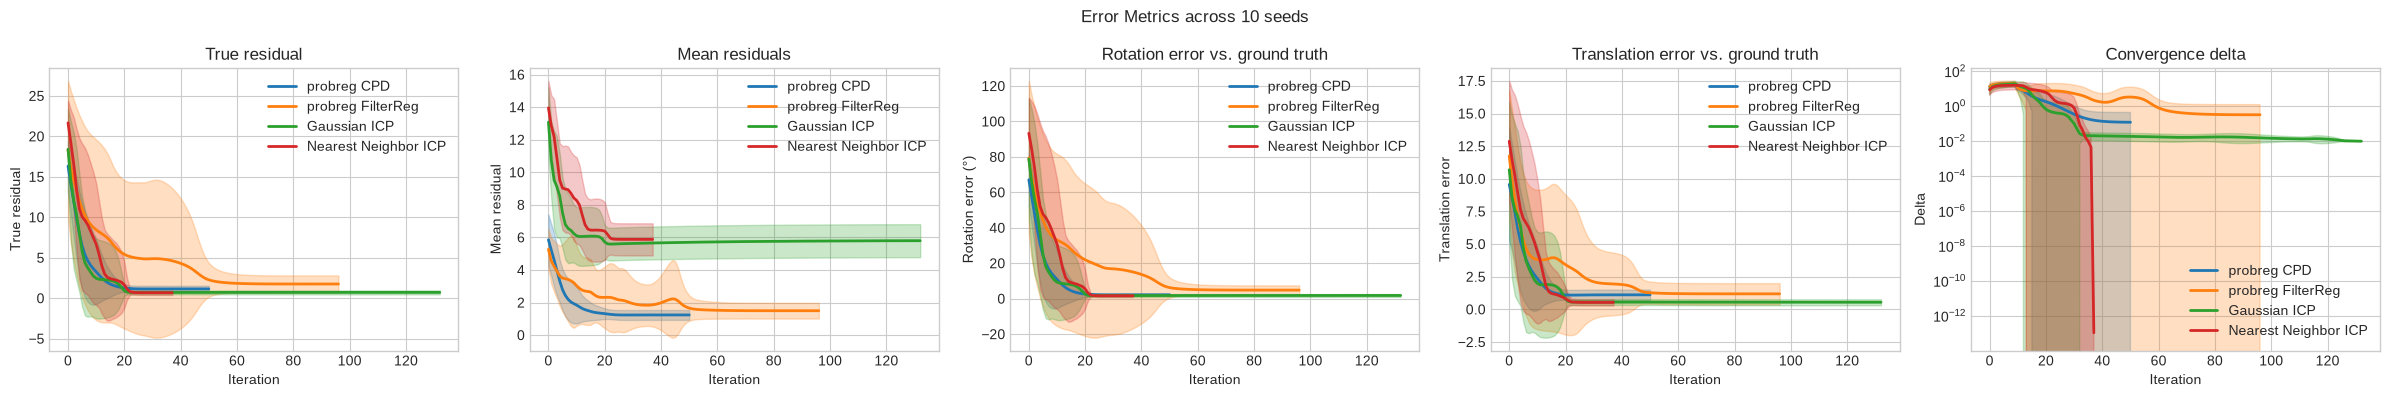

In [4]:
method_labels = ["probreg CPD", "probreg FilterReg", "Gaussian ICP", "Nearest Neighbor ICP"]
ms_results = [ms_result_cpd, ms_result_filterreg, ms_result_gaussian, ms_result_nn]

ErrorMetricsVisualizer.plot_convergence(
    results_per_method=[r.results for r in ms_results],
    experiments_per_method=[r.experiments for r in ms_results],
    method_labels=method_labels,
)
plt.suptitle(f"Error Metrics across {N_SEEDS} seeds")
plt.tight_layout()
plt.savefig('../results/9_cpd_vs_icp_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
rows: list[tuple[str, Any, Any, Any, Any, Any]] = [
    ("Method", "Convergence Ratio", "Global Optimum Ratio", "Mean True Residuals", "Final Rotation Errors (°)", "Final Translation Errors"),
]
for label, ms_result in zip(method_labels, ms_results):
    rows.append((
        label,
        convergence_ratio(ms_result.results),
        convergence_to_global_opt_ratio(ms_result.mean_true_residuals, tol=1.0),
        f"{np.mean(ms_result.mean_true_residuals):.2f} +- {np.std(ms_result.mean_true_residuals):.2f}",
        f"{np.mean(ms_result.rotation_errors):.2f} +- {np.std(ms_result.rotation_errors):.2f}",
        f"{np.mean(ms_result.translation_errors):.2f} +- {np.std(ms_result.translation_errors):.2f}",
    ))

print(tabulate(rows, headers="firstrow", tablefmt="rounded_grid", floatfmt=".4f"))

╭──────────────────────┬─────────────────────┬────────────────────────┬───────────────────────┬─────────────────────────────┬────────────────────────────╮
│ Method               │   Convergence Ratio │   Global Optimum Ratio │ Mean True Residuals   │ Final Rotation Errors (°)   │ Final Translation Errors   │
├──────────────────────┼─────────────────────┼────────────────────────┼───────────────────────┼─────────────────────────────┼────────────────────────────┤
│ probreg CPD          │              1.0000 │                 0.4000 │ 1.15 +- 0.40          │ 2.18 +- 0.54                │ 1.11 +- 0.40               │
├──────────────────────┼─────────────────────┼────────────────────────┼───────────────────────┼─────────────────────────────┼────────────────────────────┤
│ probreg FilterReg    │              1.0000 │                 0.2000 │ 1.75 +- 1.06          │ 4.84 +- 2.67                │ 1.19 +- 0.82               │
├──────────────────────┼─────────────────────┼────────────────────────

## Solving duration

Note: all four methods now run `MultiStartICP` with `n_starts=13`, so this is a fair comparison of *work done* (13 restarts each) — but not a fair comparison of *wall-clock parallelism*: the probreg methods run their 13 starts **sequentially** (`n_jobs=1`, required — see the `methods` cell), while the plain ICP variants run theirs **in parallel** across CPU cores (`n_jobs=-1`). So the probreg bars reflect the full sequential cost of 13 runs, while the ICP bars are divided across however many cores are available.

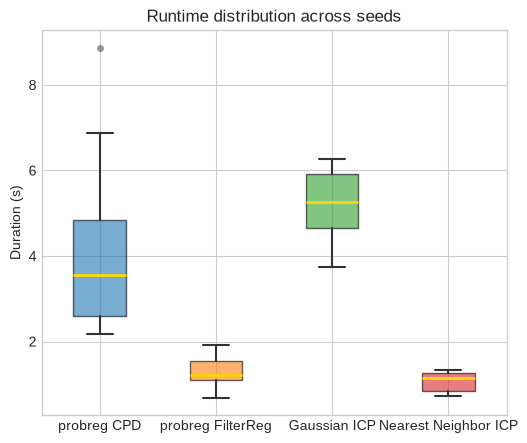

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

TimeVisualizer.plot_duration_distribution(
    ax=ax,
    durations_per_method=[np.array(r.durations_s) for r in ms_results],
    method_labels=method_labels,
)
plt.show()